# EDA for Anomaly / Fraud Detection

This notebook provides basic exploratory data analysis (EDA) for the anomaly detection dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os

# Ensure we are in the root directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

sns.set_theme(style="whitegrid")

In [2]:
# Load config
with open('configs/default.yaml', 'r') as f:
    config = yaml.safe_load(f)

data_path = config['data']['data_path']
target_col = config['data']['target_column']

print(f"Data path: {data_path}")
print(f"Target column: {target_col}")

Data path: data/raw/creditcard.csv
Target column: Class


In [3]:
# Load data
try:
    df = pd.read_csv(data_path)
    print("Data loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Data file not found. Please ensure the dataset is downloaded to data/raw/")

Data loaded successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic info
if 'df' in locals():
    print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Class distribution
if 'df' in locals():
    class_counts = df[target_col].value_counts()
    class_ratios = df[target_col].value_counts(normalize=True) * 100
    
    print("--- Class Distribution ---")
    print(class_counts)
    print("\n--- Class Ratios (%) ---")
    print(class_ratios)

--- Class Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64

--- Class Ratios (%) ---
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


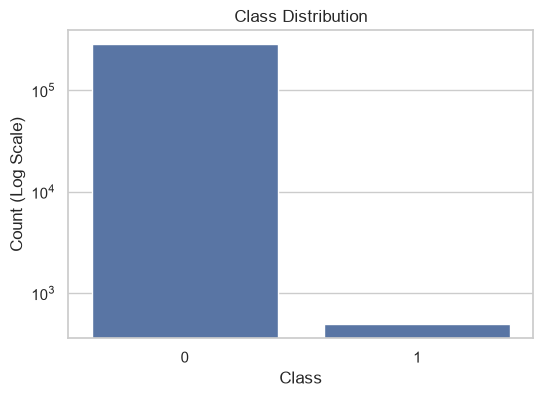

In [6]:
# Plot Class Distribution
if 'df' in locals():
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col)
    plt.title('Class Distribution')
    plt.yscale('log') # Log scale is often needed for highly imbalanced data
    plt.ylabel('Count (Log Scale)')
    plt.show()